**Inclass : Classification in Machine Learning**
    
- Part of Comprehensive Data Science and Machine Learning
- Course Length: 9 Hours
- Last Updated: August 2025

---

- Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

In [1]:
# package untuk perhitungan matematika
import math
import numpy as np
from scipy.special import expit

# package untuk persiapan data
import pandas as pd

# package untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# package untuk handling imbalance dataset
from imblearn.under_sampling import RandomUnderSampler

In [2]:
# package untuk keperluan modeling
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, RocCurveDisplay

<div style="background-color:#d18b49; text-align: center; margin: 0 auto; color: black;">

# 🌳 Decision Tree🌳

</div>

Decision Tree adalah model yang terbilang cukup sederhana, namun performanya *robust/powerfull* dan hasilnya *dapat diinterpretasi* dengan mudah. Model decision tree merupakan dasar dari *tree-based model* lainnya seperti Random Forest yang terkenal robust untuk menghasilkan prediksi.

Decision tree akan menghasilkan **pohon keputusan** berdasarkan pola yang terdapat pada data. Hasilnya diinterpretasikan dalam sebuah **rule-based** sehingga dapat dipahami dengan mudah bagaimana model tersebut melakukan prediksi.

Karakter tambahan decision tree:

* Mengasumsikan antar variabel prediktor saling independen
* Decision tree dapat mengatasi outlier

## Struktur

Untuk lebih memahami decision tree, mari kita lihat struktur sederhana dari decision tree dan istilah-istilah yang sering dipakai. Di bawah ini adalah decision tree untuk menentukan apakah kita akan *beraktifitas keluar atau tidak* weekend ini:

![](assets/strucutre.PNG)

* **Root Node**: Cabang pertama, berupa variabel yang paling utama digunakan untuk menentukan nilai target
* **Interior Node**: Cabang kedua dan seterusnya, berupa variabel lain yang digunakan apabila cabang pertama tidak cukup untuk menentukan target
* **Leaf/Terminal Node**: Nilai target atau kelas yang diprediksi

Pertanyaan selanjutnya, bagaimana Decision Tree memilih predictor pada setiap percabangannya?

- Secara intuitif, Decision Tree memilih predictor yang sebisa mungkin meng-**homogen**-kan target variable pada leaf node nya. Contoh: Observasi 100% Yes ketika Outlook (cuaca) bernilai Overcast (berawan).
- Tingkat kehomogenan ini dapat dihitung menggunakan **Entropy** dan **Information Gain**.


## Entropy & Information Gain

**Bagaimana rule terbentuk?**

Decision Tree membuat rule dengan *memilih predictor yang dapat membuat homogen target*. Oleh karena itu pemilihannya berdasarkan,

- **Entropy**: tingkat kehomogenan data
  - 0 -> semakin seragam/teratur/homogen (semuanya yes/semuanya no)
  - 1 -> semakin beragam/tidak teratur/non-homogen (50:50 yes dan no)
  
> Kelompok data yang diharapkan setelah dilakukan percabangan adalah kelompok yang memiliki entropy rendah.

Untuk memilih prediktor mana yang menjadi root node, dihitunglah **perubahan entropy** yaitu selisih antara entropy sebelum dan sesudah dilakukan percabangan menggunakan variable predictor.
  
- **Information Gain**: penurunan entropy, sebelum vs setelah percabangan

Predictor yang dipilih adalah predictor yang menghasilkan **penurunan entropy paling besar**, berarti membuat data setelah pemisahan semakin homogen. Perubahan entropy inilah yang disebut **Information Gain**.

> Prediktor yang dipilih pada setiap percabangan adalah predictor yang menghasilkan information gain terbesar.

Contoh: 

Misalkan saya mencatat perilaku saya dalam menentukan **apakah saya pergi makan ke restoran/tidak** sebagai berikut:

### 🍔 Study Case : Do i need to go `Dineout` or not? 🍔

In [3]:
dine = pd.read_csv("data_input/dineout.csv", sep= ";")
dine

,Budget,Distance,Friend,Dine Out
0,High,Far,Available,Yes
1,High,Far,Absent,No
2,Low,Near,Absent,No
3,High,Near,Absent,Yes
4,Low,Far,Absent,No
5,High,Near,Absent,Yes
6,Low,Near,Available,No
7,Low,Far,Available,No
8,Low,Near,Available,No
9,High,Far,Absent,No


- `Budget`: Budget yang saya miliki (High atau Low)
- `Distance`: Jarak restoran dari rumah saya (Far atau Near)
- `Friend`: Apakah ada teman yang menemani? (Available atau Absent)
- `Dine.Out`: Keputusan apakah makan di restoran atau tidak (Yes atau No)

🔻 Misalnya disini kita memiliki kasus, apakah akan pergi makan keluar atau tidak dimana kita memiliki 8 kejadian tidak keluar dan 4 kejadian keluar.
Maka entropy dari kejadian adalah sebagai berikut : 

![](assets/dineout.PNG)

**💡 KEY POINTS**

Untuk membuat Decision Tree, diinginkan prediktor yang:

* menghasilkan entropy data setelah splitting: rendah
* menghasilkan information gain: tinggi

<div style="background-color:#ed8ab3; text-align: center; margin: 0 auto; color: black;">

## 📊🌳 Decision Tree Machine Learning Workflow : Machine Equipment Failure Prediction 📊🌳

</div>

Pada bagian ini, kita akan menggunakan dataset `equipment_data.csv` untuk memprediksi apakah mesin akan mengalami kegagalan atau tidak dengan menggunakan model Decision Tree.


### 1️⃣ Import data

In [4]:
# Read data
equipment = pd.read_csv("data_input/equipment_data.csv", sep=",")

**Deskripsi Kolom:**

- `temperature`: Suhu pada saat pengamatan (dalam °C).
- `pressure`: Tekanan pada saat pengamatan (dalam bar).
- `vibration`: Tingkat getaran yang terukur (dalam satuan yang sudah di normalisasi).
- `humidity`: Persentase kelembapan yang tercatat di lokasi peralatan.
- `equipment`: Jenis alat industri yang dipantau (misalnya: Turbin, Kompresor, Pompa).
- `location`: Lokasi peralatan (nama kota).
- `faulty`: Indikator biner (0 = Tidak Bermasalah, 1 = Bermasalah) untuk menunjukkan apakah peralatan berfungsi dengan baik atau memerlukan perawatan.

### 2️⃣ Data Preparation

#### 🟢 <u> Mengubah tipe data </u>

Sebelum melakukan perubahan tipe data, silahkan cek terlebih dahulu jenis tipe datanya dengan menggunakan method `dtypes`/`info()`

In [5]:
# code here
equipment.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


❓ Kolom apa saja yang belum memliki tipe data yang tepat?

- 

Mengubah beberapa tipe data secara bersamaan

In [6]:
# code here
cat_columns = ['location', 'equipment']
equipment[cat_columns] = equipment[cat_columns].astype('category')



In [7]:
# code here
equipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   temperature  7672 non-null   float64 
 1   pressure     7672 non-null   float64 
 2   vibration    7672 non-null   float64 
 3   humidity     7672 non-null   float64 
 4   equipment    7672 non-null   category
 5   location     7672 non-null   category
 6   faulty       7672 non-null   float64 
dtypes: category(2), float64(5)
memory usage: 315.1 KB


#### 🟢 <u> Cek Missing Value </u>

Dalam pengecekan *missing values* disediakan fungsi `isna()` yang dapat mengecek ke setiap baris data dan menunjukan *logical value*. Untuk mempermudah pengecekannya, fungsi tersebut dapat digabungkan dengan fungsi `.sum()`.

In [8]:
# code here
equipment.isna().sum()

temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64

#### 🟢 <u> Cek Duplicate Data </u>

Dalam pengecekan *nilai duplikat* disediakan sebuah fungsi `duplicated()` yang dapat mengecek ke setiap baris data dan menunjukan *logical value*. Untuk mempermudah pengecekannya, fungsi tersebut dapat digabungkan dengan fungsi `.any()`.

In [9]:
# code here
equipment.duplicated().sum()

0

#### 🟢 <u> Outlier </u>

Adakah terdapat outlier pada data yang perlu untuk dihapus?

In [10]:
equipment

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0
...,...,...,...,...,...,...,...
7667,65.711521,37.505934,2.030521,49.331471,Pump,New York,0.0
7668,63.005855,45.164234,1.264585,61.905390,Pump,New York,0.0
7669,72.029230,34.757896,1.709046,49.972917,Pump,Atlanta,0.0
7670,107.086485,23.754114,1.142522,23.967977,Compressor,Atlanta,1.0


<Axes: >

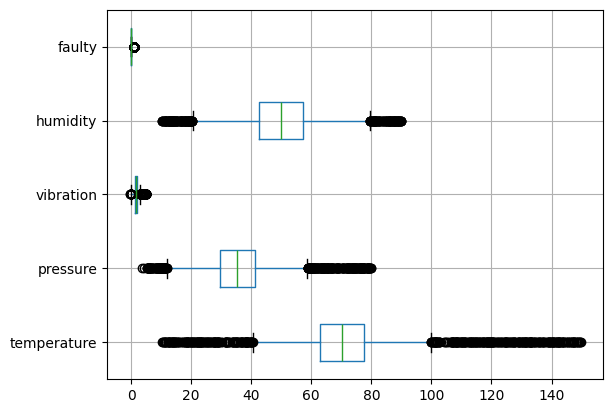

In [11]:
# code here
num_columns = equipment.select_dtypes('number').columns.to_list()

equipment.boxplot(column = num_columns, vert = False)

💡 **Insight:**

### 3️⃣ Exploratory Data Analysis (EDA)

#### 🟢<u> Analisis `describe()` </u>

Pada tahapan ini kita akan mencoba untuk melakkan analisis apakah terdapat sebuah hal yang menarik dari hasil fungsi `describe()` untuk masing-masing kelas target

**Kelas Target *Kategori* : 1**

In [12]:
# code here
equipment[equipment['faulty'] == 1].describe()



,temperature,pressure,vibration,humidity,faulty
count,767.000000,767.000000,767.000000,767.000000,767.0
mean,79.880024,42.038679,2.554807,50.466058,1.0
std,40.440541,21.373942,1.430705,22.952035,0.0
min,10.269385,5.165296,0.006115,10.215077,1.0
25%,44.291098,23.675173,1.335757,29.886102,1.0
50%,81.831306,41.766484,2.581200,52.001998,1.0
75%,114.949838,60.299983,3.799604,69.914474,1.0
max,149.690420,79.887734,4.990537,89.984718,1.0


**Kelas Target *Kategori* : 0**

In [13]:
# code here
equipment[equipment['faulty'] == 0].describe()

,temperature,pressure,vibration,humidity,faulty
count,6905.000000,6905.000000,6905.000000,6905.000000,6905.0
mean,69.927484,35.038181,1.507062,49.966645,0.0
std,10.012077,8.010232,0.502891,9.865363,0.0
min,37.587327,3.620798,-0.428188,13.449135,0.0
25%,63.230049,29.711800,1.166388,43.083716,0.0
50%,69.918868,35.049052,1.508354,49.999388,0.0
75%,76.620518,40.410856,1.851252,56.686298,0.0
max,109.262377,62.431284,3.739542,86.113501,0.0


### 4️⃣ Data Pre-Processing

Terdapat 2 hal yang biasanya dilakukan pada tahapan data pre-processing yaitu **Variable Encoding** dan juga **Cross Validation**

#### 🟢 <u> Variable Encoding </u>

Apa yang dimaksud dengan ***Encoding*** dan kenapa harus dilakukan? 

Di Python, data input dan output untuk model *machine learning* harus berbentuk numeric. Ini berarti, ketika data kita mempunyai nilai kategorikal, harus di-*encode* menjadi numerik sebelum dimasukkan ke dalam pemodelan dan evaluasi machine learning.

![](assets/categorical-type.png)


Data kategorikal adalah data yang mengandung nilai label alih-alih nilai numerik. Tipe data kategorikal terbagi menjadi dua, yaitu:

1. Nominal: Tipe kategorikal yang tidak memiliki hubungan antara kategori satu dengan yang lainnya. Contoh: kota (Jakarta, Makassar, Bandung), warna (biru, putih, hitam), hewan (kucing, sapi, ayam).

2. Ordinal: Tipe kategorikal yang memiliki hubungan bertingkat. Contoh: tingkat pendidikan (s1, s2, s3), tingkat kepuasan (kecewa, netral, puas), pengalaman kerja (junior, mid, senior).


📢 **Diskusi:** 

Dari variable yang kita miliki, manakah yang termasuk ordinal encoding dan nominal encoding?

**Jawab:**

* Nominal : 
* Ordinal : 

#### 🟢 <u> Nominal Encoding di Python </u>

Implementasi nominal encoding memiliki perbedaan dengan ordinal encoding, apabila dalam ordinal encoding label kategorikal di ganti dengan nilai yang memiliki bobot, maka dalam nominal encoding yang akan di cek adalah kemunculan nilai dalam suatu baris. 

Berikut adalah gambaran nominal encoding: 

![x](assets/one_hot-dummy.png)

Implementasi pada Python:

- Dilakukan dengan menggunakan fungsi `pd.get_dummies()`
- **One hot encoding** = mengubah kolom kategorik menjadi kolom-kolom baru dari setiap kategori yang berisi nilai 0 dan 1 
- **Dummy variable** =  mengubah kolom kategorik menjadi kolom-kolom baru yang terdiri dari **k-1 kategori**, berisi nilai 0 dan 1. Kategori yang tidak menjadi kolom, akan menjadi kondisi basis. Untuk membuat dummy variable, tambahkan parameter `drop_first=True`

In [14]:
equip_dummy = pd.get_dummies(data=equipment, 
                             columns=['location', 'equipment'], 
                             drop_first=True, 
                             dtype=int)

equip_dummy.head()

,temperature,pressure,vibration,humidity,faulty,location_Chicago,location_Houston,location_New York,location_San Francisco,equipment_Pump,equipment_Turbine
0,58.180180,25.029278,0.606516,45.694907,0.0,0,0,0,0,0,1
1,75.740712,22.954018,2.338095,41.867407,0.0,1,0,0,0,0,0
2,71.358594,27.276830,1.389198,58.954409,0.0,0,0,0,1,0,1
3,71.616985,32.242921,1.770690,40.565138,0.0,0,0,0,0,1,0
4,66.506832,45.197471,0.345398,43.253795,0.0,0,0,1,0,1,0


#### 🟢 <u> Cross Validation </u>

*Cross Validation* adalah metode yang kita gunakan untuk mengetahui seberapa baik performa model kita memprediksi terhadap data baru.

Lantas, bagaimana cara mengetahui apakah model yang kita buat telah baik dalam memprediksi data baru? Di sinilah mengapa kita melakukan Train-test splitting. Kita membagi data kita menjadi 2 kelompok, yaitu data `train` dan `test`.

<img src="assets/test-trainn.png" width="600"/>

- Data `train`: Data yang model gunakan untuk training.

- Data `test`: Data untuk evaluasi model (Untuk melihat seberapa baik model memprediksi terhadap data yang tidak digunakan untuk training)

📌 **Analogi sederhana**

- Seorang siswa dapat dikatakan pintar ketika dapat menjawab benar soal-soal ujian yang tidak pernah dikerjakannya pada soal-soal latihan untuk persiapan ujian.
- Data `train` diibaratkan soal latihan, dan data `test` diibaratkan soal ujian. Adapun `model` kita diibaratkan sebagai siswa.


Kita dapat menggunakan fungsi `train_test_split` dengan beberapa parameter sebagai berikut.
- `arrays`: dataframe yang kita gunakan (dipisah , untuk yang prediktor dan target variable)
- `test_size`: jumlah persentase dari data yang akan digunakan sebagai data test
- `train_size`: jumlah persentase dari data yang akan digunakan sebagai data test (akan otomatis terisi jika `test_size` diberi nilai)
- `random_state`: nilai random number generator (RNG). Jika kita memasukkan suatu nilai integer untuk parameter ini maka akan menghasilkan hasil yang sama untuk nilai yang sama. Jika kita mengubah nilainya, maka hasilnya akan berbeda.

> **💡 NOTES**: Biasanya data dibagi menjadi 80:20 atau 70:30 (train size:test size). Porsi yang besar selalu digunakan untuk training

In [15]:
from sklearn.model_selection import train_test_split

# memisahkan prediktor dan target
# target
y = equip_dummy['faulty']

# all predictor except the target
X = equip_dummy.drop(columns=['faulty'])    

# Cross validation
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size=0.2,
                                                    random_state=123)

❓ **Mengapa kita perlu mengunci sifat random yang ada?**

- Agar kita mendapatkan hasil antara data train dan data test yang sama 
- Ketika kita ingin melakukan adjustment/tunning pada model yang sudah ada, data yang akan dimasukan kembali ke model tersebut sama dengan model yang sebelumnya. Sehingga kita bisa melakukan komparasi yang apple to apple terhadap kedua model tersebut.

#### 🟢 <u> Balancing Data </u>

**Cek Proporsi Kelas Target**

Setelah melakukan cross validation, kita perlu memastikan bahwa proporsi kelas target kita sudah seimbang atau belum.

❓ **Mengapa kita harus mencari tau proporsi targetnya seimbang/tidak?**

- Proporsi yang seimbang penting untuk agar model dapat mempelajari karakteristik kelas positif maupun negatif secara seimbang
- Dalam kata lain, tidak hanya belajar dari satu kelas saja. Hal ini mencegah model dari *hanya baik memprediksi 1 kelas saja*

Dalam melakukan pengecekan, pandas sudah menyediakan sebuah fungsi `crosstab()`. Pada fungsi tersebut akan di-isi dengan 3 parameter yaitu

- `index`: parameter ini akan di-isi dengan target data train kita
- `columns`: parameter ini akan di-isi dengan target variable
- `normalize`: dapat di-isi dengan True untuk menunjukan hasil dalam bentuk persentase.

In [16]:
# Code here
pd.crosstab(index=y_train, columns='count')

col_0,count
faulty,
0.0,5517
1.0,620


Proporsi yang imbalance sebenarnya cukup subjektif dan tidak ada aturan bakunya. Akan tetapi ketika proporsinya targetnya *90%:10%* atau *95%:5%*, target variable tersebut akan dianggap tidak seimbang.

**Action Plan ketika datanya imbalance:**

- Tambah data real -> memerlukan waktu
- Metode *downSampling* -> Membuang observasi dari kelas mayoritas, sehingga seimbang.
- Metode *upSampling* -> Duplikasi observasi dari kelas minoritas, sehingga seimbang.

![](assets/downsample_upsample.png)

✏️ **Note:** 

- *Data yang cukup banyak* dalam artian frekuensi datanya cukup banyak untuk kelas minoritas. Ini bisa dilihat dari proporsi kelas target. Jika ternyata terdapat 1000 data namun ternyata 800 kelas mayoritas, dan 200 kelas minoritas, setelah downsampling jadi ada 400 data, datanya masih cukup sedikit. Usahakan jumlah data minoritas setidaknya 300 observasi.
- Bila data masih terlalu sedikit dan tidak ingin melakukan upsampling, berarti kita harus menambah data.

🔻 **Kita akan menggunakan upsample karena data minoritas kurang dari 1000 observasi**

- Metode OverSample sudah disediakan dari submodule `RandomOverSampler` dari module `imbalanced-learn`. Pada module tersebut terdapat fungsi `RandomOverSampler()` yang diperuntukkan untuk melakukan duplikasi pada kelas minoritas hingga memiliki frekuensi yang sama dengan kelas mayoritas.
- Selanjutnya, gunakan fungsi `fit_resample()` untuk implementasi ke data equipment.

✏️ **Note:** Untuk downsample kita dapat import submodule [`RandomUnderSampler`](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [17]:
# import library
from imblearn.over_sampling import RandomOverSampler

# ambil beberapa sample data mayoritas
oversampler = RandomOverSampler(random_state=123)

# Implementasi
X_train_up, y_train_up = oversampler.fit_resample(X_train, y_train)

Check proporsi kelas

In [18]:
# code here
pd.crosstab(index=y_train_up, columns='count')


col_0,count
faulty,
0.0,5517
1.0,5517


In [19]:
df_up = pd.concat([X_train_up, y_train_up], axis=1)

In [20]:
df_up.duplicated().sum()

4897

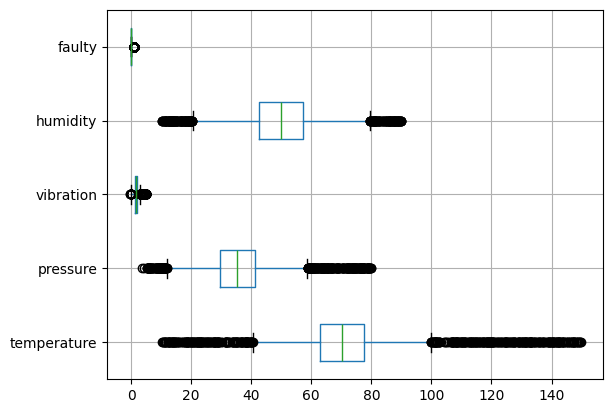

In [21]:
# code here
num_columns = equipment.select_dtypes('number').columns.to_list()

equipment.boxplot(column = num_columns, vert = False)
plt.show()

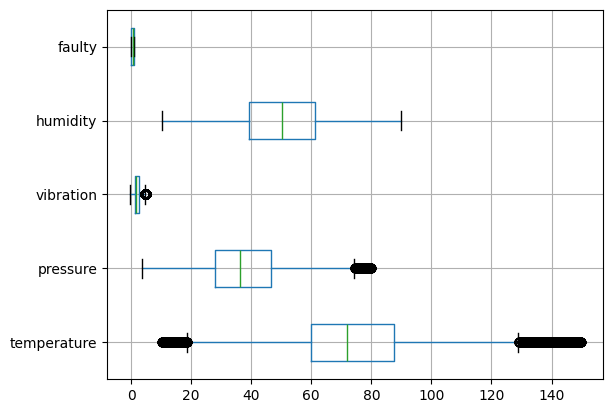

In [22]:
df_up.boxplot(column = num_columns, vert = False)
plt.show()

💡 **Insight:**

### 5️⃣ Model Fitting

Untuk membuat model decision tree, kita dapat menggunakan fungsi `DecisionTreeClassifier()` yang termasuk dalam `sklearn.tree` module.

Pada fungsi tersebut, terdapat parameter yang dapat diisikan yaitu:
- `random_state =`  Parameter ini untuk mengunci sifat random pemasukan data

Seperti biasa, ketika ingin melakukan fitting model, maka kita gunakan `.fit()`. Pada fungsi `.fit()` kita dapat memasukkan informasi prediktor dan target variabel kita.

#### 🟢 Model Initialization & Fitting

In [23]:
# import library
from sklearn.tree import DecisionTreeClassifier

# model initialization
dt_equipment = DecisionTreeClassifier(random_state=123)

# fit model
dt_equipment.fit(X_train_up, y_train_up)


DecisionTreeClassifier(random_state=123)

#### 🟡 [Optional] Visualization & Interpretation 

Yang menarik dari decision tree yaitu, kita memperoleh **rule-based** yang dapat kita interpretasikan. Rule based ini dapat kita visualisasikan sebagai pohon keputusan. Untuk memvisualisasikannya, kita dapat menggunakan fungsi `plot_tree` dari `matplotlib` package.

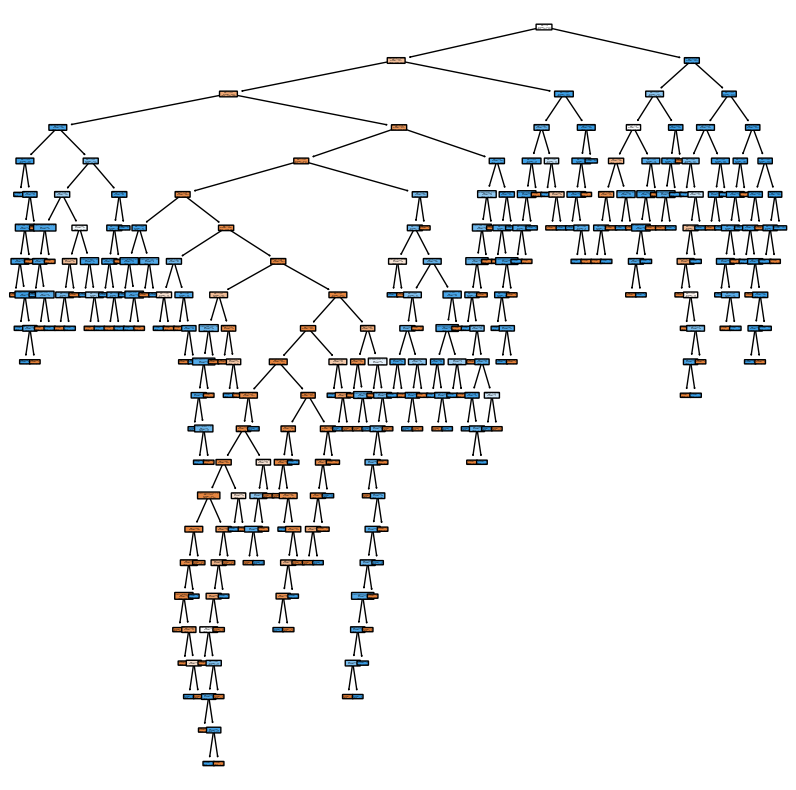

In [24]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# visualization
plt.figure(figsize=(10,10))
plot_tree(dt_equipment, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True)
plt.show()

In [25]:
# menampilkan plot


Kita juga dapat mengeksport rules yang ada pada model decision tree yang sudah dibuat dengan bantuan function `export_text()`

In [26]:
from sklearn.tree import export_text
tree_text = export_text(dt_equipment, feature_names=X_train.columns.to_list())
print(tree_text)

|--- vibration <= 2.45
|   |--- temperature <= 96.48
|   |   |--- temperature <= 46.36
|   |   |   |--- temperature <= 40.59
|   |   |   |   |--- temperature <= 37.35
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- temperature >  37.35
|   |   |   |   |   |--- vibration <= 1.45
|   |   |   |   |   |   |--- location_New York <= 0.50
|   |   |   |   |   |   |   |--- temperature <= 37.77
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- temperature >  37.77
|   |   |   |   |   |   |   |   |--- equipment_Turbine <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |--- equipment_Turbine >  0.50
|   |   |   |   |   |   |   |   |   |--- vibration <= 1.29
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- vibration >  1.29
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- location_New York >  0.50
|   |   |   |   |   |   |   |--- class

💡 **Insight :** Salah satu karakteristik dari `Decision Tree` adalah model ini sangat detail dalam membuat pohonnya, bahkan bisa sampai ada 1 observasi pada leaf node nya. 
Hal ini membuat decision tree justru *menghafal* pola di data train, dan membuat aturan yang terlalu kompleks, bukan *mempelajari* pola tersebut. Alhasil model menjadi kurang general untuk diaplikasikan ke data yang bukan data train, sehingga cenderung overfit. 

Maka dari itu, ada suatu metode yang dapat digunakan untuk melakukan pemotongan pada tree yang terbentuk. Pemotongan/pencegahan cabang pohon itu dinamakan **Pruning**

#### 🌳🪓 Model Tuning - Pruning and Tree-Size 🌳🪓

Pruning terbagi menjadi 2 cara:

* **Pre-Pruning**: Terlebih dahulu memasang parameter sebelum model dihasilkan. Metode ini kurang disarankan karena kita belum memiliki informasi tentang parameter apa yang sebaiknya kita atur (harus menduga).

* **Post-Pruning**: Pruning setelah kita mendapatkan model yang lengkap atau kompleks, lalu menentukan seberapa jauh kita akan memangkas cabang pada Decision Tree.

Pruning yang akan kita lakukan akan diimplementasikan pada saat pembentukan model Decision Tree dengan menambahkan beberapa parameter:

* **max_depth**: kedalaman maksimum pohon untuk membuat cabang
* **min_samples_split**: Jumlah minimal observasi di interior node sebelum pemisahan. Bila tidak terpenuhi, tidak dilakukan percabangan. 
* **min_samples_leaf**: Jumlah minimal observasi di terminal node. Bila tidak terpenuhi, tidak dilakukan percabangan. 

Sekarang kita akan coba melakukan hyperparameter tuning pada model sebelumnya dengan mengatur:
- max_depth : 3
- min_samples_split : 10
- min_samples_leaf : 5

**Notes:**

Untuk membuat model tree yang lebih sederhana, kita dapat memperbesar nilai `min_sample_split` dan `min_samples_leaf`

In [27]:
# code here
dt_equipment_tuning = DecisionTreeClassifier(max_depth = 3,
                                      min_samples_split = 15,
                                      min_samples_leaf=10,
                                      random_state = 123)

# fitting
dt_equipment_tuning.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=15,
                       random_state=123)

In [28]:
# visualization
plt.figure(figsize=(15,15), dpi=150)
plot_tree(dt_equipment_tuning, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True);

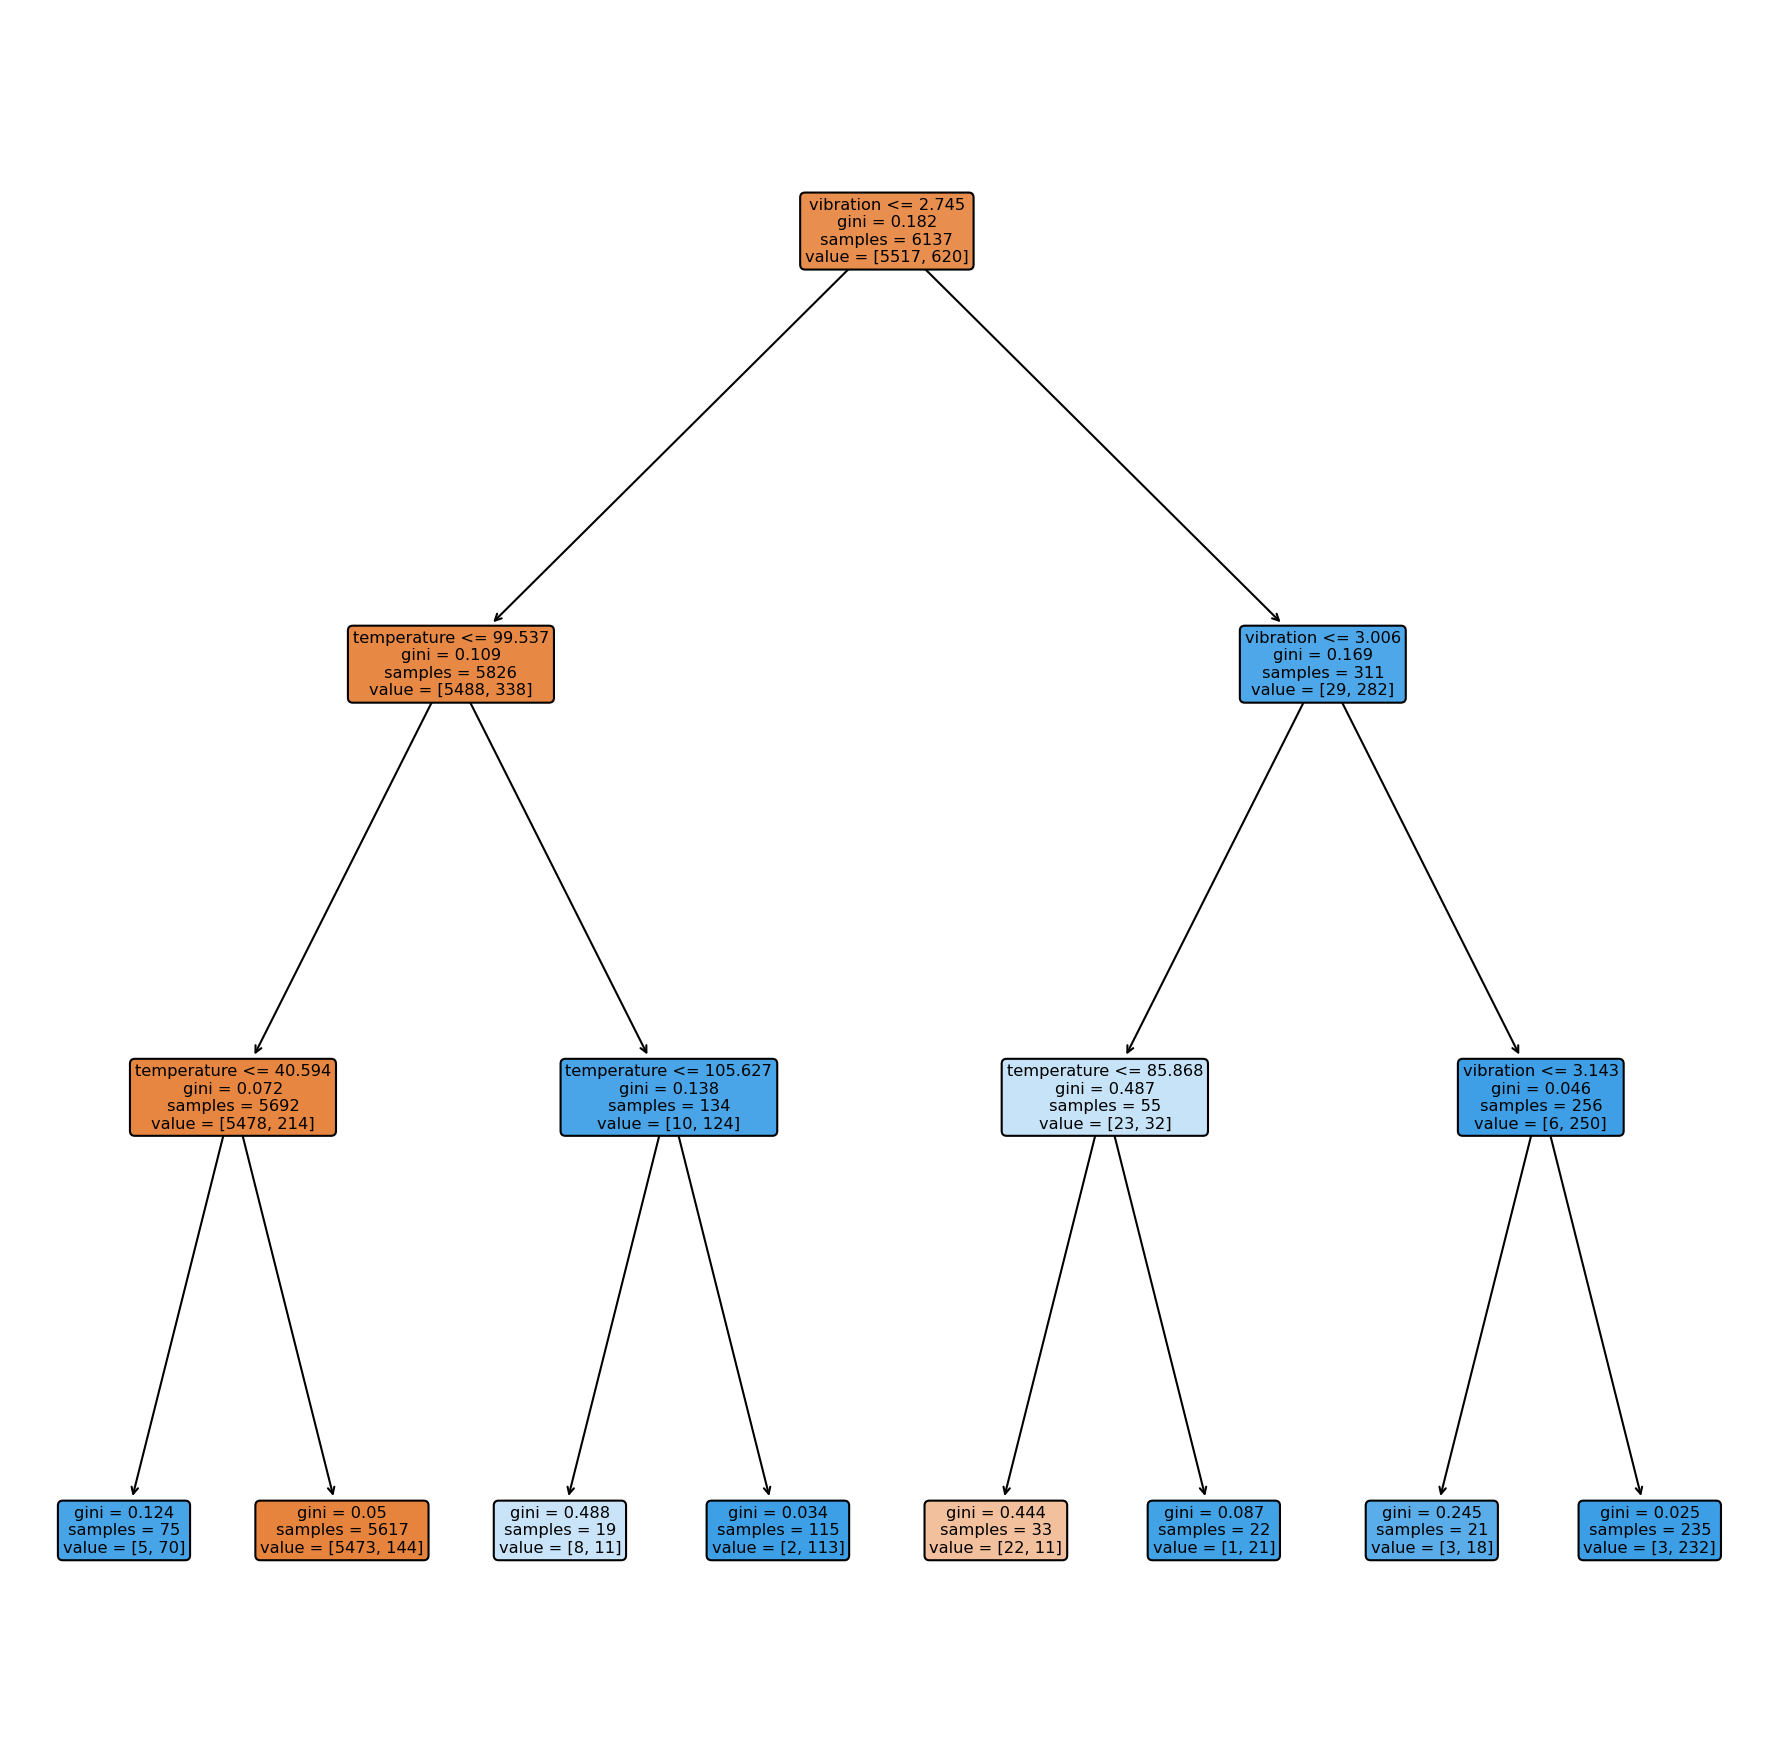

In [29]:
# menampilkan plot DT
plt.show()


In [30]:
# Export text
tree_text = export_text(dt_equipment_tuning, feature_names=X_train.columns.to_list())
print(tree_text)

|--- vibration <= 2.74
|   |--- temperature <= 99.54
|   |   |--- temperature <= 40.59
|   |   |   |--- class: 1.0
|   |   |--- temperature >  40.59
|   |   |   |--- class: 0.0
|   |--- temperature >  99.54
|   |   |--- temperature <= 105.63
|   |   |   |--- class: 1.0
|   |   |--- temperature >  105.63
|   |   |   |--- class: 1.0
|--- vibration >  2.74
|   |--- vibration <= 3.01
|   |   |--- temperature <= 85.87
|   |   |   |--- class: 0.0
|   |   |--- temperature >  85.87
|   |   |   |--- class: 1.0
|   |--- vibration >  3.01
|   |   |--- vibration <= 3.14
|   |   |   |--- class: 1.0
|   |   |--- vibration >  3.14
|   |   |   |--- class: 1.0



#### 🟢 Interpretasi model

Interpretasi dari rules yang terbuat akan sangat berguna untuk orang teknis menetahui alasan mengapa suatu data diklasifikasikan pada kelas tertentu.

Rules yang terbentuk adalah sebagai berikut:
- ...
- ...

### 6️⃣ Model Predict

Setelah melakukan pembuatan model dan melakukan pemotongan pada pohon, mari kita lakukan prediksi terhadap data test yang ada.


1. Predict dengan `dt_equipment`

In [31]:
# model dt equipment
pred_dt_equipment = dt_equipment.predict(X_test)

2. Predict dengan `dt_equipment_tuning`

In [32]:
# model dt equipment tuning
pred_dt_equipment_tuning = dt_equipment_tuning.predict(X_test)

### 7️⃣ Model Evaluation

Setelah dilakukan prediksi menggunakan model, masih ada saja prediksi yang salah. Pada klasifikasi, kita mengevaluasi model berdasarkan **confusion matrix**:

Langkah berikutnya setelah dilakukan prediksi menggunakan model adalah melakukan evaluasi. Pada klasifikasi, kita mengevaluasi model berdasarkan **confusion matrix**.

- Penentuan kelas:
  + kelas positif: kelas yang menjadi concern/amatan
  + kelas negatif: kelas yang tidak menjadi concern/amatan

- Contoh kasus: 
  + Machine learning untuk deteksi pasien cancer:
    * kelas positif: terdeteksi cancer
    * kelas negatif: terdeteksi sehat

- Isi dari Confusion Matrix:

  * True Positive (TP): diprediksi positif dan benar (prediksi positif; aktual positif)
  * True Negative (TN): diprediksi negatif dan benar (prediksi negatif; aktual negatif) 
  * False Positive (FP): diprediksi positif namun salah (prediksi positif; aktual negatif)
  * False Negative (FN): diprediksi negatif namun salah (prediksi negatif; aktual positif)
    
![](assets/tnfp.PNG)

1. Confusion Matrix `dt_equipment`

In [33]:
# confusion matrix
pd.crosstab(index = pred_dt_equipment,
            columns = y_test,
            rownames=['Prediksi'],
            colnames=['Actual'])

Actual,0.0,1.0
Prediksi,,
0.0,1371,25
1.0,17,122


2. Confusion Matrix `dt_equipment_tuning`

In [34]:
# confusion matrix
pd.crosstab(index = pred_dt_equipment_tuning, 
            columns = y_test,
            rownames=['Prediksi'],
            colnames=['Actual'])

Actual,0.0,1.0
Prediksi,,
0.0,1383,38
1.0,5,109


Metrics performa model: **Accuracy, Sensitivity/Recall, Precision**

- **Accuracy**: seberapa tepat model kita memprediksi kelas target (secara global)   
- **Sensitivity**/ **Recall**: ukuran kebaikan model terhadap kelas `positif`    
- Pos Pred Value/**Precision**: seberapa presisi model memprediksi kelas positif  

#### 🟢 <u> Accuracy </u>

Seberapa banyak yang benar diprediksi dari keseluruhan data (positif maupun negatif).

$$\frac{TP+TN}{TOTAL}$$

1. Accuracy `dt_equipment`

In [35]:
# code here
from sklearn.metrics import accuracy_score
accuracy_dt = accuracy_score(y_test, pred_dt_equipment)
print(f'Accuracy DT: {accuracy_dt:.4f}')

accuracy_dt_tuning = accuracy_score(y_test, pred_dt_equipment_tuning)
print(f'Accuracy DT Tuning: {accuracy_dt_tuning:.4f}')

Accuracy DT: 0.9726
Accuracy DT Tuning: 0.9720


2. Accuracy `dt_equipment_tuning`

In [36]:
# code here


📌 Note: tidak ada batasan mutlak berapa akurasi yang dianggap akurat (sudah baik):

* dikembalikan ke kebutuhan bisnis masing-masing. 
  + Misalkan medis untuk diagnosis penyakit perlu akurasi yang sangat tinggi
  + Sementara di bidang pemasaran, akurasi bisa saja tidak perlu setinggi itu

📌 Nilai akurasi digunakan ketika:

* kelas target sama penting
* data balance

Secara general, nilai akurasi, makin mendekati satu, makin baik

Ada kondisi ketika **accuracy bukanlah metrics terpenting**. Umumnya ketika:

- kita mementingkan salah satu kelas (misal, kelas target/positif)
- data kita imbalance

Saat kita mementingkan kelas tertentu, maka kita dapat memilih antara menggunakan metrics Recall / Precision: 

#### 🟢 <u> Sensitivity/Recall </u>

Seberapa banyak yang **benar diprediksi positif**, dari yang **reality**-nya (aktualnya) positif.

$$\frac{TP}{(TP+FN)}$$

1. Recall `dt_equipment`

In [37]:
# code here


2. Recall `dt_equipment_tuning`

In [38]:
# code here


### 🟢 <u> Precision/Pos Pred Value </u>

Seberapa banyak yang **benar diprediksi positif**, dari yang di**prediksi** positif. 

$$\frac{TP}{(TP+FP)}$$

1. Precision `dt_equipment`

In [39]:
# code here
from sklearn.metrics import precision_score
precision_dt = precision_score(y_test, pred_dt_equipment)
print(f'Precision DT: {precision_dt:.4f}')
precision_dt_tuning = precision_score(y_test, pred_dt_equipment_tuning)
print(f'Precision DT Tuning: {precision_dt_tuning:.4f}')

Precision DT: 0.8777
Precision DT Tuning: 0.9561


2. Precision `dt_equipment_tuning`

In [40]:
# code here


🟡 **Cara Cepat:**

1. Evaluation dengan `dt_equipment`

In [41]:
print(f'Accuracy score: {accuracy_score(y_test, pred_dt_equipment)}')
print(f'Recall score: {recall_score(y_test, pred_dt_equipment )}')
print(f'Precision score: {precision_score(y_test, pred_dt_equipment)}')

Accuracy score: 0.9726384364820847
Recall score: 0.8299319727891157
Precision score: 0.8776978417266187


2. Evaluation dengan `dt_equipment_tuning`

In [42]:
print(f'Accuracy score: {accuracy_score(y_test, pred_dt_equipment_tuning)}')
print(f'Recall score: {recall_score(y_test, pred_dt_equipment_tuning)}')
print(f'Precision score: {precision_score(y_test, pred_dt_equipment_tuning)}')

Accuracy score: 0.971986970684039
Recall score: 0.7414965986394558
Precision score: 0.956140350877193


✍️ **Model Final:** 

Tahapan pemilihan recall/precision pada evaluasi model:

1. Definisikan kelas positif
2. Pahami resiko paling concerning dari kesalahan prediksi (lihat dari FN dan FPnya)
3. Pilih metric recall atau precision

#### 🟢 Bias-Variance Tradeoff

Dalam pembuatan model, model berusaha mempelajari pola yang terdapat dalam data sehingga dihasilkan suatu aturan yang dapat memprediksi kelas/nilai target dengan tepat. Untuk masing-masing model machine learning, terdapat karakteristik yang disebut *bias* dan *variance*.

* **bias**: perbedaan antara hasil prediksi dengan nilai aktual
* **variance**: variasi hasil prediksi yang mungkin muncul pada titik data tertentu

![](assets/underfitting_overfitting.png)

Kekurangan dari Decision Tree adalah kecenderungannya untuk overfitting. Hal ini terjadi karena Decision tree mampu membagi-bagi data hingga amat detail (bahkan hingga dalam leaf node hanya terdapat 1 observasi). Hal ini membuat decision tree justru *menghafal* pola di data train, dan membuat aturan yang terlalu kompleks, bukan *mempelajari* pola tersebut. Alhasil model menjadi kurang general untuk diaplikasikan ke data yang bukan data train, sehingga cenderung overfit. 

**Kondisi Model:**

- **Overfitting**: model baik di data train, namun amat buruk di data test $\rightarrow$ tidak diinginkan
  - karena model terlalu kompleks (misal, decision tree -> tree prunning)
  - 10 - 15% perbedaanya pada metriks data train dan data test
    Contoh: Recall di data train 80% dan Recall di data test 70%
- **Underfitting**: model buruk di data train maupun di data test $\rightarrow$ tidak diinginkan
  - Contoh: Recall di data train 50% dan Recall di data test 40%
  - karena model terlalu sederhana (misal, linear/log regression -> ganti model)
- **Just Right**: model baik di data train, dan pada data test menurun sedikit (selisih < 0.1) $\rightarrow$ yg kita inginkan
  - 10 - 15% perbedaanya pada metriks data train dan data test

Untuk melihat apakah model yang kita miliki adalah model yang cukup baik (dalam hal ini tidak overfit maupun underfit) kita akan coba mengeceknya dengan melakukan **evaluasi pada data train** dan membandingkannya dengan **evaluasi pada data test**:

1. Model Predict untuk Data Train dan Data Test

**Data Train**

In [43]:
# code here
pred_dt_equipment_train = dt_equipment.predict(X_train)
print(f'Accuracy score (train): {accuracy_score(y_train, pred_dt_equipment_train)}')
print(f'Recall score (train): {recall_score(y_train, pred_dt_equipment_train )}')
print(f'Precision score (train): {precision_score(y_train, pred_dt_equipment_train)}')


Accuracy score (train): 1.0
Recall score (train): 1.0
Precision score (train): 1.0


In [46]:
# code here
pred_dt_equipment_tuning_train = dt_equipment_tuning.predict(X_train_up)
print(f'Accuracy score (train): {accuracy_score(y_train_up, pred_dt_equipment_tuning_train)}')
print(f'Recall score (train): {recall_score(y_train_up, pred_dt_equipment_tuning_train )}')
print(f'Precision score (train): {precision_score(y_train_up, pred_dt_equipment_tuning_train)}')


Accuracy score (train): 0.8716693855356172
Recall score (train): 0.747326445531992
Precision score (train): 0.9946924004825091


**Data Test**

In [ ]:
# code here


2. Model Evaluation untuk Data Train dan Data Test

**Data Train**

In [ ]:
# code here


**Data Test**

In [ ]:
# code here


---

# Ensemble Methods

Ensemble methods adalah metode pembelajaran yang menggabungkan prediksi dari beberapa model machine learning menjadi 1 prediksi tunggal. 

## Wisdom of the Crowd

Salah satu cara untuk menekan bias dan variance sekaligus adalah dengan **menggabungkan prediksi dari beberapa model menjadi 1 prediksi tunggal**. Gabungan beberapa model machine learning ini disebut dengan **Ensemble Method**. Ensemble method bertujuan untuk meningkatkan performa model dalam memprediksi. Salah satu contoh ensemble method yang merupakan pengembangan dari decision tree adalah **Random Forest**.

<div style="background-color:#d18b49; text-align: center; margin: 0 auto; color: black;">

# 🌳🌳Random Forest🌳🌳

</div>

## Memahami Random Forest

Random Forest adalah salah satu jenis Ensemble Method. Random Forest melakukan prediksi dengan membuat **banyak Decision Tree**. Masing-masing Decision Tree memiliki karakteristik masing-masing dan tidak saling berhubungan satu sama lain. Random Forest kemudian melakukan prediksi untuk masing-masing decision tree, kemudian dari sekian banyak hasil prediksi tersebut dilakukan voting. Kelas dengan jumlah terbanyak akan menjadi hasil prediksi final. Random Forest memanfaatkan konsep bernama **Bagging: Bootstrap and Aggregation**. Berikut adalah proses yang terjadi:

1. Membuat data dengan random sampling dari data yang ada dan mengizinkan adanya duplikat (**Bootstrap sampling**)
2. Membuat decision tree dari masing-masing data hasil bootstrap sampling, digunakan prediktor sebanyak `mtry` yang juga dipilih secara random
3. Melakukan prediksi data baru untuk setiap decision tree
4. Melakukan majority voting untuk menentukan hasil prediksi final (**Aggregation**)

![](assets/random_forest.PNG)

**Kelebihan**:
- Mereduksi bias sekaligus variance dari decision tree
- Robust untuk prediction
- Automatic Feature Selection pemilihan prediktor secara otomatis & random pada pembuatan decision tree
- Out-of-Bag error pengganti evaluasi model ke data test

## Basic Implementation

Dengan menggunakan kasus yang sama, kita akan melakukan training menggunakan `RandomForestClassifier` dengan parameter default (membuat 100 pohon)

Pada fungsi tersebut nantinya kita akan mengisinya dengan beberapa parameter, seperti

- `oob_score =`: apakah akan menggunakan out-of-bag samples untuk evaluasi atau tidak
- `n_estimators =`: banyaknya tree yang akan dibuat

Selain dari 2 parameter tersebut, terdapat parameter-parameter dari Decision Tree yang sudah kita gunakan.

* `max_depth`: kedalaman maksimum pohon untuk membuat cabang
* `min_samples_split`: Jumlah minimum sampel yang diperlukan untuk memisahkan internal/interior node. Bila tidak terpenuhi, tidak dilakukan percabangan. 
* `min_samples_leaf`: Jumlah minimum sampel yang diperlukan untuk berada pada leaf node. Pada setiap percabangan akan dihitung jumlah sampel minimum pada cabang kanan atau kiri sebanyak nilai min_sample_leaf.

### 5️⃣ Model Fitting

In [47]:
# import library
from sklearn.ensemble import RandomForestClassifier

# model intialize 
rf_equipment = RandomForestClassifier(random_state=100, 
                                   oob_score = True, 
                                   n_estimators= 100,
                                   max_depth=40,
                                   min_samples_split=10,
                                   min_samples_leaf=5)

In [ ]:
# model training
rf_equipment.fit(X_train_up, y_train_up)

RandomForestClassifier(max_depth=40, min_samples_leaf=5, min_samples_split=10,
                       oob_score=True, random_state=100)

### 6️⃣ Model Predict

**Data Train**

In [50]:
# code here
pred_train_rf = rf_equipment.predict(X_train_up)
print(f'Accuracy score (train): {accuracy_score(y_train_up, pred_train_rf)}')
print(f'Recall score (train): {recall_score(y_train_up, pred_train_rf )}')
print(f'Precision score (train): {precision_score(y_train_up, pred_train_rf)}')

Accuracy score (train): 0.9448069603045133
Recall score (train): 0.8926953054196121
Precision score (train): 0.9965600971266694


**Data Test**

In [51]:
# code here
pred_test_rf = rf_equipment.predict(X_test)
print(f'Accuracy score (test): {accuracy_score(y_test, pred_test_rf)}')
print(f'Recall score (test): {recall_score(y_test, pred_test_rf )}')
print(f'Precision score (test): {precision_score(y_test, pred_test_rf)}')

Accuracy score (test): 0.9804560260586319
Recall score (test): 0.8707482993197279
Precision score (test): 0.920863309352518


### 7️⃣ Model Evaluation

**Data Train**

In [52]:
# code here
#print(f'Recall score: {recall_score(___, ___)}')

**Data Test**

In [53]:
# # code here
# print(f'Recall score: {recall_score(___, ___)}')
# print(f'Precision score: {precision_score(___, ___)}')
# print(f'Accuracy score: {accuracy_score(___, ___)}')

#### 🟢 Out of Bag Error

Meskipun sebelumnya kita melakukan splitting data dan dapat mengevaluasi data menggunakan data_test, sebenarnya kita **tidak perlu melakukan cross-validation** saat menggunakan random forest. Hal ini karena dari hasil **boostrap sampling**, terdapat data-data yang tidak digunakan dalam pembuatan random forest. Data-data tersebut adalah **out-of-bag data** dan dianggap sebagai *data test* oleh model. Model akan melakukan prediksi dengan data tersebut dan menghitung akurasi model yang dihasilkan. Akurasi tersebut disebut sebagai **out-of-bag score**.

In [54]:
# cek oob_score
rf_equipment.oob_score_

0.9812612025419586

### 8️⃣ Variable Importance

Yang menarik dari random forest, walaupun model yang kita miliki sangat out of the box, kita dapat mengetahui variabel yang dianggap penting. Untuk mengetahui tingkat kepentingan dari suatu variabel kita dapat menggunakan tingkat impurity suatu variabel.

Semakin tinggi, semakin penting fitur tersebut. Pentingnya suatu fitur dihitung sebagai pengurangan total (dinormalisasi) dari kriteria yang dibawa oleh fitur tersebut.

Mari kita buat plot di mana kita mendapatkan 10 fitur terpenting. 

In [55]:
# Mengeluarkan nilai 10 fitur yang dianggap paling penting
importances = rf_equipment.feature_importances_
feature_names = X_train.columns
feature_importances = pd.Series(importances, index=feature_names)
top_10_features = feature_importances.sort_values(ascending=False).head(10)
print(top_10_features)

vibration                 0.351172
temperature               0.318736
pressure                  0.210022
humidity                  0.113966
equipment_Pump            0.001427
location_Houston          0.001137
equipment_Turbine         0.001117
location_Chicago          0.000923
location_San Francisco    0.000815
location_New York         0.000684
dtype: float64


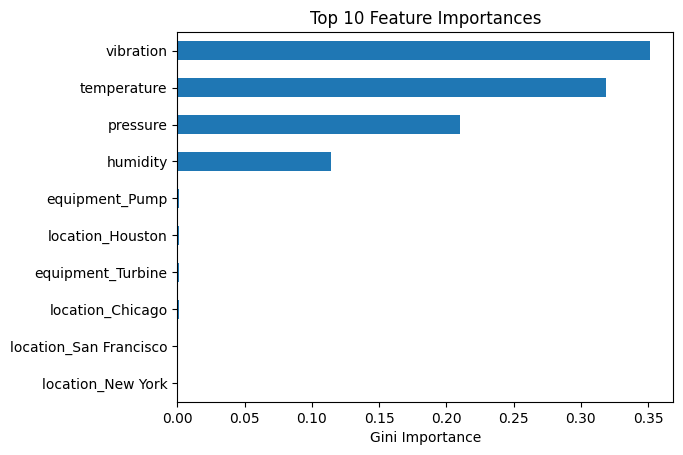

In [59]:
# Visualization
pd.Series(
    rf_equipment.feature_importances_,
    index=X_train.columns
    ).sort_values().tail(10).plot.barh(title="Top 10 Feature Importances", xlabel='Gini Importance');
plt.show()